### TASK 04

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Major Cities in Pakistan by population.csv")
print(df.shape)

(100, 6)


In [3]:
print(df.columns)

Index(['Rank', 'City', 'Population 2017 Census', 'Population 1998 Census',
       'Change', 'Province'],
      dtype='object')


In [4]:
print(df.head())

   Rank        City  Population 2017 Census  Population 1998 Census  Change  \
0     1     Karachi                14916456                 9339023  0.5972   
1     2      Lahore                11126285                 5209088  1.1359   
2     3  Faisalabad                 3204726                 2008861  0.5953   
3     4  Rawalpindi                 2098231                 1409768  0.4884   
4     5  Gujranwala                 2027001                 1132509  0.7898   

  Province  
0    Sindh  
1   Punjab  
2   Punjab  
3   Punjab  
4   Punjab  


In [5]:
print(df.dtypes)

Rank                        int64
City                       object
Population 2017 Census      int64
Population 1998 Census      int64
Change                    float64
Province                   object
dtype: object


# Cleaning Checks

In [6]:
print(df.isnull().sum())

Rank                      0
City                      0
Population 2017 Census    0
Population 1998 Census    0
Change                    0
Province                  0
dtype: int64


In [7]:
print("Duplicate rows" , df.duplicated().sum())

Duplicate rows 0


In [8]:
invalde_p = df[df['Population 2017 Census'] <= 0]
print(len(invalde_p))

0


In [9]:
print(df.describe())

             Rank  Population 2017 Census  Population 1998 Census      Change
count  100.000000            1.000000e+02            1.000000e+02  100.000000
mean    50.500000            6.021669e+05            3.490538e+05    0.800580
std     29.011492            1.872231e+06            1.082203e+06    0.497305
min      1.000000            1.001350e+05            3.461500e+04    0.075300
25%     25.750000            1.241170e+05            7.090350e+04    0.487875
50%     50.500000            1.752730e+05            1.038950e+05    0.678750
75%     75.250000            3.580535e+05            1.926292e+05    0.909000
max    100.000000            1.491646e+07            9.339023e+06    3.177500


In [10]:
province_population = df.groupby("Province")["Population 2017 Census"].sum()
province_population = province_population.sort_values(ascending= False)

In [11]:
print(province_population)

Province
Punjab                32868778
Sindh                 20449259
Khyber Pakhtunkhwa     3918298
Balochistan            1696256
Islamabad              1009832
Azad Kashmir            274265
Name: Population 2017 Census, dtype: int64


In [12]:
cities_per_province = df["Province"].value_counts()
print(cities_per_province)

Province
Punjab                59
Sindh                 22
Khyber Pakhtunkhwa    11
Balochistan            5
Azad Kashmir           2
Islamabad              1
Name: count, dtype: int64


In [13]:
avg_growth_per_province = df.groupby("Province")["Change"].mean().sort_values(ascending=False)
print(avg_growth_per_province)

Province
Balochistan           1.371380
Sindh                 0.935105
Islamabad             0.908300
Khyber Pakhtunkhwa    0.802073
Punjab                0.713022
Azad Kashmir          0.414700
Name: Change, dtype: float64


In [14]:
mean_pop= np.mean(df["Population 2017 Census"])

In [15]:
print(mean_pop)

602166.88


In [16]:
print(f"Mean Population : {mean_pop:.0f}")

Mean Population : 602167


### 5 smallest cities by population

In [17]:
smallest_cities = df.sort_values("Population 2017 Census").head(5)

print("Five Smallest Major Cities by Population")
print(smallest_cities[["City", "Population 2017 Census"]])

Five Smallest Major Cities by Population
                   City  Population 2017 Census
99              Bhalwal                  100135
98             Kandhkot                  100698
97       Mirpur Mathelo                  100760
96      Kamber Ali Khan                  101474
95  Tando Muhammad Khan                  101863


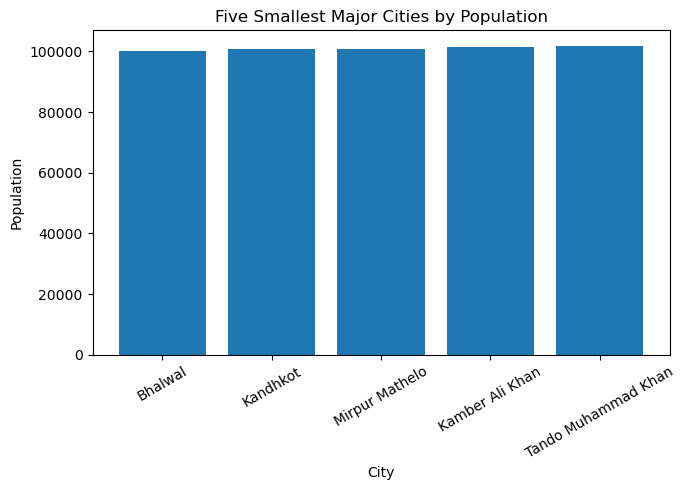

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.bar(smallest_cities["City"], smallest_cities["Population 2017 Census"])
plt.xlabel("City")
plt.ylabel("Population")
plt.title("Five Smallest Major Cities by Population")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Highest Average Growth Rate by Province

In [19]:
average_growth=df.groupby("Province")["Change"].mean()
highest_growth=average_growth.sort_values(ascending=False)
print(highest_growth)
print("Province with Highest Average Growth is:",average_growth.idxmax())

Province
Balochistan           1.371380
Sindh                 0.935105
Islamabad             0.908300
Khyber Pakhtunkhwa    0.802073
Punjab                0.713022
Azad Kashmir          0.414700
Name: Change, dtype: float64
Province with Highest Average Growth is: Balochistan


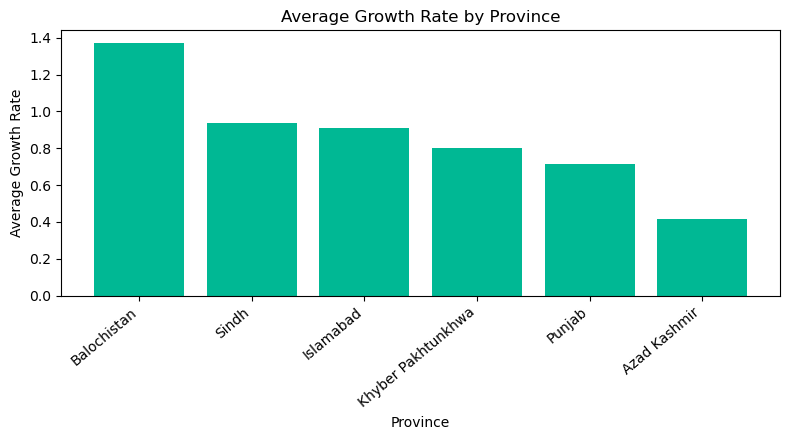

In [20]:
plt.figure(figsize=(8,4.5))
plt.bar(highest_growth.index, highest_growth.values, color="#00b894")
plt.xlabel("Province")
plt.ylabel("Average Growth Rate")
plt.title("Average Growth Rate by Province")
plt.xticks(rotation= 40 , ha = "right")
plt.tight_layout()
plt.show()

### Cities With Population above 1M

In [21]:
cities_above_1m=df[df["Population 2017 Census"]>1000000]
print("Number of Cities Above 1 Million Population are:" , len(cities_above_1m))

Number of Cities Above 1 Million Population are: 10


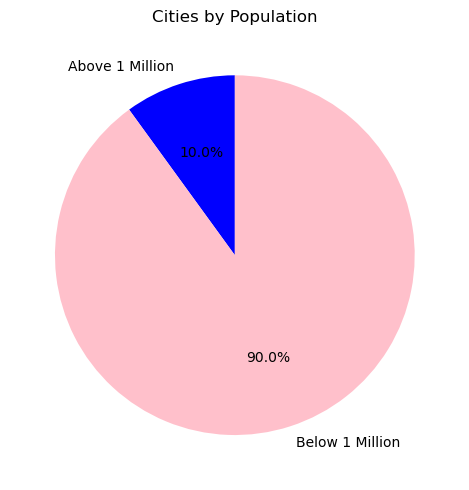

In [22]:
above_1m = len(df[df["Population 2017 Census"] > 1000000])
below_1m = len(df[df["Population 2017 Census"] <= 1000000])
plt.figure(figsize=(5,5))
plt.pie([above_1m, below_1m],labels=["Above 1 Million", "Below 1 Million"],autopct="%1.1f%%",startangle=90,
        colors=["#0000FF","#FFC0CB"])
plt.title("Cities by Population")
plt.tight_layout()
plt.show()

### Difference b/w mean and median Population

In [23]:
mean_population = df["Population 2017 Census"].mean()
median_population = df["Population 2017 Census"].median()
difference = mean_population - median_population
print("Mean Population =", mean_population)
print("Median Population =", median_population)
print("Difference =", difference)

Mean Population = 602166.88
Median Population = 175273.0
Difference = 426893.88


#### The mean is much higher than the median because a few large cities like Karachi and Lahore have very high populations which increase the mean while the median is less affected by these extreme values.

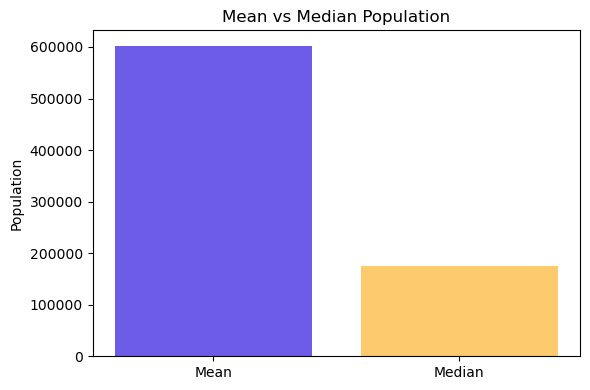

In [24]:
plt.figure(figsize=(6,4))
plt.bar(["Mean", "Median"],[mean_population, median_population], color=["#6c5ce7","#fdcb6e"])
plt.ylabel("Population")
plt.title("Mean vs Median Population")
plt.tight_layout()
plt.show()